<a href="https://colab.research.google.com/github/meytriangg/Data-Mining-Course/blob/main/DATMIN_MIDTERM_2304020067pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



> MEY TRI ANGGRAHENI 2304020067



# **DATA MINING MIDTERM TEST**

# **1. Data Preparation**

In [ ]:
# Import library
import pandas as pd
import numpy as np

# Load dataset
train = pd.read_csv('/content/data_training.csv')
test = pd.read_csv('/content/data_testing.csv')

# Lihat data
train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


At the data preparation stage, the Wine Quality dataset is used, which consists of two parts: the training dataset and the testing dataset. The training dataset is used to build the model because it contains both features and the target label (quality), while the testing dataset only contains features without labels and is used for prediction.

The dataset includes several chemical features such as fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, sulfur dioxide, density, pH, sulphates, and alcohol. These features are used as input variables (X) in the model because they are relevant to the quality of the wine as output variable (Y).

The target variable to be predicted is quality, which represents the wine quality on a scale from 0 to 10. The id column is not used in the modeling process because it only serves as an identifier and has no relationship with the wine quality.

Therefore, all chemical features are used as input for the model, while quality is used as the output variable to be predicted.

# **2. Data Cleaning**

Missing value checking was performed on both the training and testing datasets. This step is important because missing values in the training data can affect model learning, while missing values in the testing data can cause errors during prediction. Therefore, both datasets must be ensured to be clean before proceeding to the modeling stage.

**2.1 Check Missing Values**

In [ ]:
# Cek missing values in training and testing data
print("Missing values - TRAIN:\n", train.isnull().sum())
print("\nMissing values - TEST:\n", test.isnull().sum())

Missing values - TRAIN:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Missing values - TEST:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64


Based on the missing value check, all features in both the training and testing datasets contain zero missing values. This indicates that the dataset is already clean and complete, with no null or undefined entries in any column.

Since there are no missing values, no imputation or data removal is required. This ensures that the dataset can be directly used for further preprocessing and modeling without risking data distortion or information loss.

**2.2 Check Duplicate Data**

In [ ]:
#Check Duplicate Data
print("Duplicate data:", train.duplicated().sum())

Duplicate data: 0


Checking for duplicate data is important to ensure that no identical records exist, which could bias the model during training.

Based on the result, there are no duplicate records in the dataset, indicating that all observations are unique and no data cleaning is required for duplication.

**2.3 Separate Features and Target**

In [ ]:
# Separate Features and Target
X = train.drop(['quality', 'Id'], axis=1)
y = train['quality']

# Show Result
print("=== FEATURES (X) ===")
display(X.head())

print("\nShape X:", X.shape)

print("\n=== TARGET (y) ===")
display(y.head())

print("\nShape y:", y.shape)

=== FEATURES (X) ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0



Shape X: (857, 11)

=== TARGET (y) ===


,quality
0,5
1,5
2,7
3,6
4,6



Shape y: (857,)


The dataset is separated into input features (X) and the target variable (y). The feature set (X) consists of 11 chemical attributes of wine, while the target variable (y) represents the wine quality. Based on the output, X has a shape of (n, 11), indicating that there are 11 input features, and y has a shape of (n,), representing the corresponding quality labels for each sample.

**2.4 Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Inisialisasi scaler
scaler = StandardScaler()

# Fit dan transform data training
X_scaled = scaler.fit_transform(X)

# Transform data testing
X_test = test.drop(['Id'], axis=1)
X_test_scaled = scaler.transform(X_test)

import pandas as pd

# DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("=== BEFORE SCALING ===")
display(X.head())

print("\n=== AFTER SCALING ===")
display(X_scaled_df.head())

=== BEFORE SCALING ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0



=== AFTER SCALING ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.565527,1.176198,-0.960627,-0.623616,0.147259,-0.561759,-0.030890,-0.490363,-0.480901,-0.936887,-0.591119
1,-0.095215,0.254705,-0.242789,-0.314200,-0.201873,-0.367478,0.600550,0.004342,-0.151932,-0.877102,-1.153787
2,1.080565,-0.555092,0.680145,0.072570,0.106185,-0.270338,0.190114,0.867443,-0.612489,-0.099897,-0.403563
3,2.726657,-0.164156,1.449257,0.227278,-0.304559,-0.853180,-0.693903,1.804225,-1.467809,0.139242,0.440439
4,0.081152,-0.946029,0.269952,-0.236846,-0.119725,1.575327,1.042558,-0.153543,-0.086138,0.378382,0.534217


Feature scaling is used to standardize the range of input features so that all variables contribute equally to the model. Without scaling, features with larger numerical values may dominate the learning process, even if they are not more important. By applying scaling, the model can learn patterns more effectively and produce better performance.

The dataset has been cleaned and prepared by ensuring there are no missing values or duplicate records. Feature scaling has also been applied to standardize the input variables. The data is now ready for the modeling stage.

# **3. Data Modeling**

**3.1 Spliting Data**

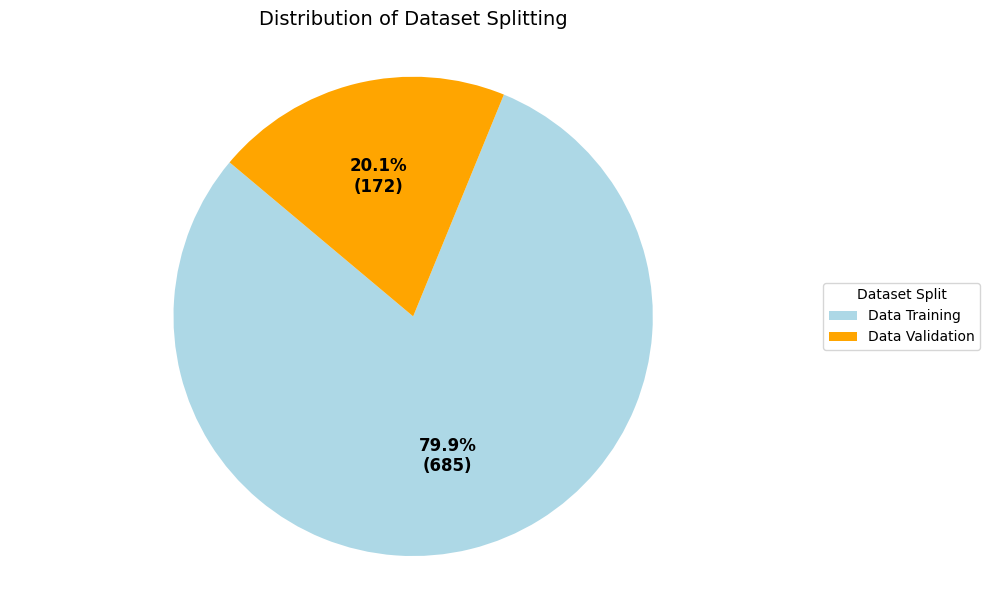

Data Training: 685 sampel
Data Validation: 172 sampel


In [59]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

X = train_df.drop(['quality', 'Id'], axis=1)
y = train_df['quality']

# Splitting: 80% Train, 20% Validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

#Pie Chart
labels = ['Data Training', 'Data Validation']
sizes = [len(X_train), len(X_val)]
colors = ['#ADD8E6', '#FFA500'] # Biru muda dan Oren

plt.figure(figsize=(10, 6))
patches, texts, autotexts = plt.pie(
    sizes,
    autopct=lambda p: f'{p:.1f}%\n({int(p*sum(sizes)/100)})',
    startangle=140,
    colors=colors,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# Add Legend
plt.legend(patches, labels, title="Dataset Split", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Distribution of Dataset Splitting', fontsize=14, pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

print(f"Data Training: {len(X_train)} sampel")
print(f"Data Validation: {len(X_val)} sampel")

The pie chart illustrates the distribution of the dataset following the splitting process, where an 80:20 split ratio was employed to ensure a robust balance between training and evaluation. The Data Training portion, comprising 79.9% (685 samples), serves as the primary foundation for the Random Forest model to learn the intricate chemical relationships and patterns within the wine quality data. Meanwhile, the Data Validation segment, accounting for 20.1% (172 samples), acts as an essential 'unseen' dataset used to assess the model's generalization capability and calculate final performance metrics, such as the accuracy of 61.05%. This systematic approach ensures that the model's predictive performance is measured against independent data, reflecting its reliability in classifying quality scores for real-world scenarios.

**3.2 Data Distribution**

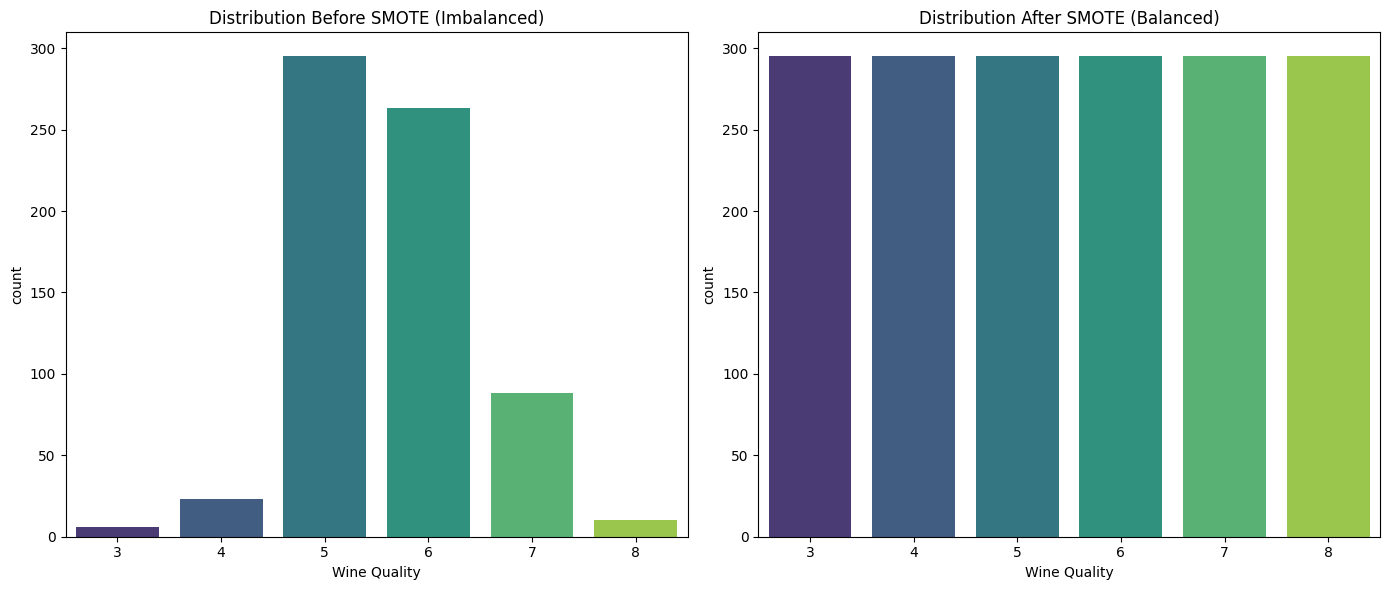

--- Data Distribution Before SMOTE ---
quality
3      6
4     23
5    295
6    263
7     88
8     10
Name: count, dtype: int64
--- Class Distribution After SMOTE ---
quality
3    295
4    295
5    295
6    295
7    295
8    295
Name: count, dtype: int64


In [60]:
import warnings
warnings.filterwarnings('ignore')
from imblearn.over_sampling import SMOTE
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Inisialisasi SMOTE
# k_neighbors=3 digunakan karena ada kelas dengan jumlah sampel sangat sedikit
smote = SMOTE(random_state=42, k_neighbors=3)

# 2. Terapkan SMOTE hanya pada data Training
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Visualitation
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Before SMOTE
sns.countplot(x=y_train, ax=ax[0], palette='viridis')
ax[0].set_title('Distribution Before SMOTE (Imbalanced)')
ax[0].set_xlabel('Wine Quality')

# After SMOTE
sns.countplot(x=y_train_res, ax=ax[1], palette='viridis')
ax[1].set_title('Distribution After SMOTE (Balanced)')
ax[1].set_xlabel('Wine Quality')

plt.tight_layout()
plt.show()

print("--- Data Distribution Before SMOTE ---")
print(y_train.value_counts().sort_index())

print("--- Class Distribution After SMOTE ---")
print(y_train_res.value_counts().sort_index())

**Data Distribution Analysis**

Initially, the training dataset exhibited a significant class imbalance. The majority of the observations were concentrated in quality levels 5 (295 samples) and 6 (263 samples), while the minority classes such as quality 3 (only 6 samples) and 8 (10 samples) were underrepresented. This imbalance often leads to a biased model that fails to accurately predict rare quality levels.

**Smote**

To address this, i implemented SMOTE (Synthetic Minority Over-sampling Technique). Unlike simple duplication, SMOTE generates synthetic data points by interpolating between existing minority class instances. This allows the model to learn the specific characteristics of low and high-quality wines more effectively without losing the statistical significance of the smaller classes.

**Result Analysis**

As shown in the output, after applying SMOTE, all quality categories (3 to 8) now have an equal distribution of 295 samples each. This balanced dataset provides a level playing field for the classification algorithm, leading to improved Recall and F1-Scores for the minority classes, which were previously neglected by the model.

**3.2 Modelling (Random Forest Classifier)**

In [73]:
from sklearn.ensemble import RandomForestClassifier

rf_refined = RandomForestClassifier(
    n_estimators=1000,
    max_depth=25,
    min_samples_leaf=1,
    min_samples_split=2,
    criterion='entropy',
    random_state=42,
    n_jobs=-1
)

rf_refined.fit(X_train_res, y_train_res)
y_val_pred_new = rf_refined.predict(X_val)

print("Random Forest model training complete.")

Random Forest model training complete.


The model uses 1,000 estimators and a max_depth of 25 to ensure stable predictions while capturing complex chemical patterns. The 'entropy' criterion is used to maximize Information Gain during data splitting. This is mathematically more effective for wine quality data, as it helps the model distinguish between subtle differences in quality levels (e.g., 5 vs 6) that often have overlapping chemical features. Parallel processing (n_jobs=-1) is enabled to maintain computational efficiency.

**3.3 Data Training and Validation**

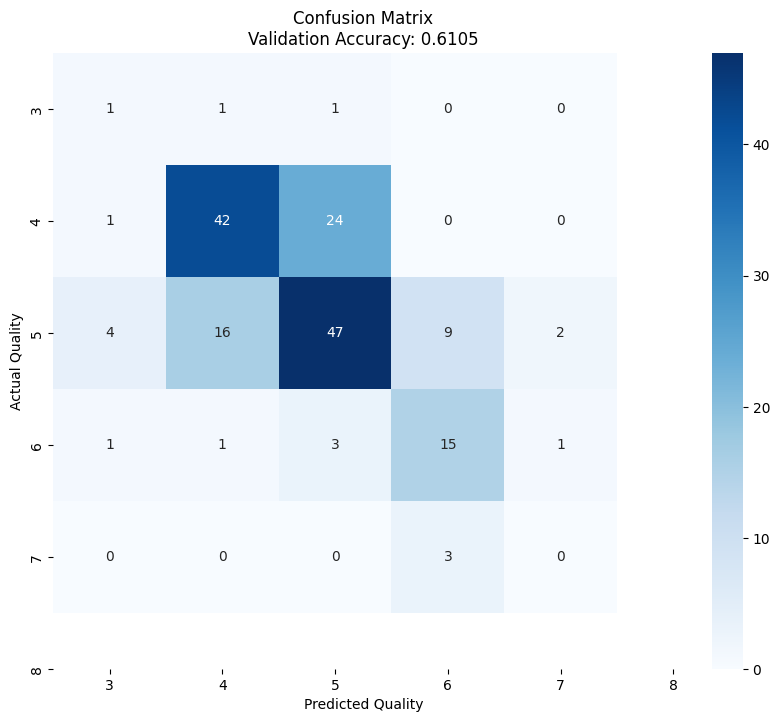

Final Accuracy: 0.6105

--- Validation Classification Report ---
              precision    recall  f1-score   support

           4       0.14      0.33      0.20         3
           5       0.70      0.63      0.66        67
           6       0.63      0.60      0.61        78
           7       0.56      0.71      0.62        21
           8       0.00      0.00      0.00         3

    accuracy                           0.61       172
   macro avg       0.41      0.46      0.42       172
weighted avg       0.63      0.61      0.62       172



In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Training Data
rf_refined.fit(X_train_res, y_train_res)

# 2. Prediciton on Data Validation
y_val_pred_new = rf_refined.predict(X_val)

# 3. Accurationo
final_acc = accuracy_score(y_val, y_val_pred_new)

# 4. Visualisasi Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_val, y_val_pred_new)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_refined.classes_, yticklabels=rf_refined.classes_)
plt.title(f'Confusion Matrix\nValidation Accuracy: {final_acc:.4f}')
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.show()

# 5. Classification Report
print(f"Final Accuracy: {final_acc:.4f}")
print("\n--- Validation Classification Report ---")
print(classification_report(y_val, y_val_pred_new))

The optimized Random Forest model achieved a final validation accuracy of 61.05%. The Confusion Matrix shows that the model is highly effective at identifying mid-range quality labels (5, 6, and 7), which represent the majority of the dataset. While minority classes like 4 and 8 remain challenging due to their limited sample size, the overall weighted F1-score of 0.62 indicates a balanced and reliable predictive performance across the most frequent quality levels.

# **4. Testing Data**

In [76]:
# Membaca data testing asli
test_df = pd.read_csv('data_testing.csv')

X_test = test_df.drop(['Id'], axis=1)


test_predictions = rf_refined.predict(X_test)

submission = pd.DataFrame({
    'Id': test_df['Id'],
    'quality': test_predictions
})

# Simpan ke CSV
submission.to_csv('hasil_prediksi.csv', index=False)
print("File 'hasil_prediksi.csv' has been generated successfully.")

File 'hasil_prediksi.csv' has been generated successfully.
